In [3]:
import numpy as np
from losses import *
from activations import *

from typing import Optional
from initializers import *
from optimizers import *
from activations import get_activation, get_activation_derivative


In [4]:
# implement compute_loss:
def compute_loss(self, y_pred: np.ndarray, y_true: np.ndarray) -> float:
    # Decide which loss to use
    if hasattr(self, 'loss') and self.loss is not None:
        loss_name = self.loss
    else:
        # basic inference: softmax outputs -> use cross-entropy, else MSE
        last_activation = getattr(self.layers[-1], 'activation', '').lower()
        loss_name = 'cross_entropy' if 'softmax' in last_activation else 'mse'

    # get the loss function from losses.py
    loss_fn = get_loss_function(loss_name)

    # compute data loss
    data_loss = loss_fn(y_pred, y_true)

    # compute L2 regularization term (only weights, not biases)
    # ensure l2_lambda exists
    l2_lambda = getattr(self, 'l2_lambda', 0.0)
    if l2_lambda and l2_lambda > 0.0:
        weights = [layer.W for layer in self.layers if hasattr(layer, 'W')]
        l2_term = l2_regularization(weights, l2_lambda)
    else:
        l2_term = 0.0

    # total loss (you may choose to average by batch outside)
    return float(data_loss + l2_term)

In [ ]:
# Test 1 (batch_size=1, output_size=3) -> expected MSE = 2.0
y_pred1 = np.array([[1.0, 2.0, 3.0]])
y_true1 = np.array([[2.0, 0.0, 4.0]])
print("MSE test1:", mean_squared_error(y_pred1, y_true1))  # -> 2.0

# Test 2 (batch_size=2, output_size=2) -> expected MSE = 1.5
y_pred2 = np.array([[0.0, 1.0],
                    [2.0, 3.0]])
y_true2 = np.array([[1.0, 1.0],
                    [1.0, 5.0]])
print("MSE test2:", mean_squared_error(y_pred2, y_true2))  # -> 1.5


loss_mse = get_loss_function('mse')

loss_mse(y_pred1,y_true1)

ced = get_loss_derivative('cross_entropy')


print(ced(2,3))

MSE test1: 2.0
MSE test2: 1.5


AttributeError: 'int' object has no attribute 'ndim'

### Vi starter her

In [5]:
import torch
from torch import nn
import torch.nn.functional as F
import torch.optim as optim
import torch.nn.init as init

%matplotlib inline
import matplotlib
import numpy as np
import matplotlib.pyplot as plt

from torch.nn.parameter import Parameter
from torchvision.datasets import MNIST

mnist_trainset = MNIST("./temp/", train=True, download=True)
mnist_testset = MNIST("./temp/", train=False, download=True)

# To speed up training we'll only work on a subset of the data
x_train = mnist_trainset.data[:1000].view(-1, 784).float()
targets_train = mnist_trainset.targets[:1000]

x_valid = mnist_trainset.data[1000:1500].view(-1, 784).float()
targets_valid = mnist_trainset.targets[1000:1500]

x_test = mnist_testset.data[:500].view(-1, 784).float()
targets_test = mnist_testset.targets[:500]

# Normalize the inputs
x_train.div_(255)
x_valid.div_(255)
x_test.div_(255)

# Print dataset shapes
print("Information on dataset")
print("x_train", x_train.shape)
print("targets_train", targets_train.shape)
print("x_valid", x_valid.shape)
print("targets_valid", targets_valid.shape)
print("x_test", x_test.shape)
print("targets_test", targets_test.shape)

Information on dataset
x_train torch.Size([1000, 784])
targets_train torch.Size([1000])
x_valid torch.Size([500, 784])
targets_valid torch.Size([500])
x_test torch.Size([500, 784])
targets_test torch.Size([500])


In [ ]:
# Hyperparameters
num_classes = 10
num_l1 = 512
num_features = x_train.shape[1]

# Define network
class Net(nn.Module):

    def __init__(self, num_features, num_hidden, num_output):
        super(Net, self).__init__()  
        # input layer
        self.W_1 = Parameter(init.xavier_normal_(torch.Tensor(num_hidden, num_features)))
        self.b_1 = Parameter(init.constant_(torch.Tensor(num_hidden), 0))
        # hidden layer
        self.W_2 = Parameter(init.xavier_normal_(torch.Tensor(num_output, num_hidden)))
        self.b_2 = Parameter(init.constant_(torch.Tensor(num_output), 0))
        # define activation function in constructor
        self.activation = torch.nn.ELU()

    def forward(self, x):
        x = F.linear(x, self.W_1, self.b_1)
        x = self.activation(x)
        x = F.linear(x, self.W_2, self.b_2)
        return x

net = Net(num_features, num_l1, num_classes)



In [ ]:
# we could have done this ourselves,
# but we should be aware of sklearn and its tools
from sklearn.metrics import accuracy_score


# setting hyperparameters and gettings epoch sizes
batch_size = 100
num_epochs = 200
num_samples_train = x_train.shape[0]
num_batches_train = num_samples_train // batch_size
num_samples_valid = x_valid.shape[0]
num_batches_valid = num_samples_valid // batch_size

# setting up lists for handling loss/accuracy
train_acc, train_loss = [], []
valid_acc, valid_loss = [], []
test_acc, test_loss = [], []
cur_loss = 0
losses = []

get_slice = lambda i, size: range(i * size, (i + 1) * size)

for epoch in range(num_epochs):
    # Forward -> Backprob -> Update params
    ## Train
    cur_loss = 0
    net.train()
    for i in range(num_batches_train):
        optimizer.zero_grad()
        slce = get_slice(i, batch_size)
        output = net(x_train[slce])
        
        # compute gradients given loss
        target_batch = targets_train[slce]
        batch_loss = criterion(output, target_batch)
        batch_loss.backward()
        optimizer.step()
        
        cur_loss += batch_loss   
    losses.append(cur_loss / batch_size)

    net.eval()
    ### Evaluate training
    train_preds, train_targs = [], []
    for i in range(num_batches_train):
        slce = get_slice(i, batch_size)
        output = net(x_train[slce])
        
        preds = torch.max(output, 1)[1]
        
        train_targs += list(targets_train[slce].numpy())
        train_preds += list(preds.data.numpy())
    
    ### Evaluate validation
    val_preds, val_targs = [], []
    for i in range(num_batches_valid):
        slce = get_slice(i, batch_size)
        
        output = net(x_valid[slce])
        preds = torch.max(output, 1)[1]
        val_targs += list(targets_valid[slce].numpy())
        val_preds += list(preds.data.numpy())
        

    train_acc_cur = accuracy_score(train_targs, train_preds)
    valid_acc_cur = accuracy_score(val_targs, val_preds)
    
    train_acc.append(train_acc_cur)
    valid_acc.append(valid_acc_cur)
    
    if epoch % 10 == 0:
        print("Epoch %2i : Train Loss %f , Train acc %f, Valid acc %f" % (
                epoch+1, losses[-1], train_acc_cur, valid_acc_cur))

epoch = np.arange(len(train_acc))
plt.figure()
plt.plot(epoch, train_acc, 'r', epoch, valid_acc, 'b')
plt.legend(['Train Accucary','Validation Accuracy'])
plt.xlabel('Updates'), plt.ylabel('Acc')

NameError: name 'net' is not defined

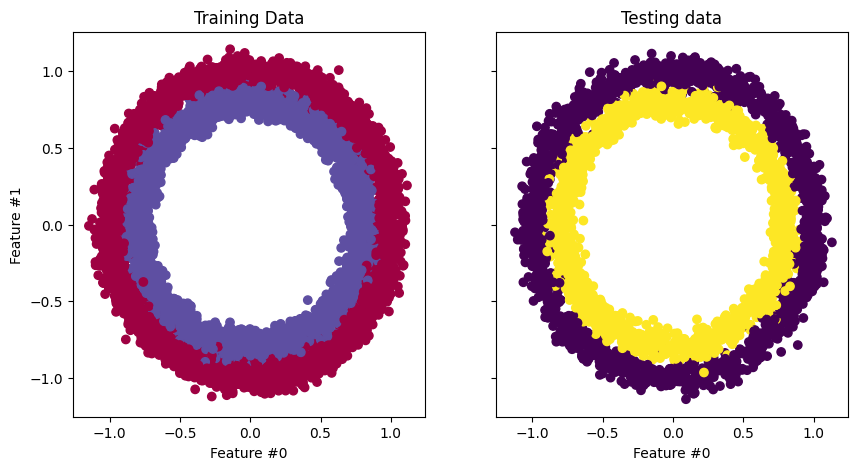

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

# Create a dataset with 10,000 samples.
X, y = make_circles(n_samples = 10000,
                    noise= 0.05,
                    random_state=26)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.33, random_state=26)

# Visualize the data.
fig, (train_ax, test_ax) = plt.subplots(ncols=2, sharex=True, sharey=True, figsize=(10, 5))
train_ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.Spectral)
train_ax.set_title("Training Data")
train_ax.set_xlabel("Feature #0")
train_ax.set_ylabel("Feature #1")

test_ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test)
test_ax.set_xlabel("Feature #0")
test_ax.set_title("Testing data")
plt.show()

## Vi starter her

In [2]:
from typing import Optional

import numpy as np

def relu(x: np.ndarray) -> np.ndarray:
    """
    Rectified Linear Unit (ReLU) activation function.
    Formula: f(x) = max(0, x)
    """
    return np.maximum(0, x)

def relu_derivative(x: np.ndarray) -> np.ndarray:
    """
    Derivative of ReLU activation.
    Returns 1 if x > 0, otherwise 0.
    Formula: f'(x) = 1 if x > 0, else 0
    Args: x: Input numpy array
    Returns: Derivative of ReLU activation
    """
    return (x > 0).astype(float)

def sigmoid(x: np.ndarray) -> np.ndarray:
    """
    Sigmoid activation function with numerical stability.
    Formula: f(x) = 1 / (1 + exp(-x))
    Args: x: Input numpy array
    Returns: Sigmoid activation output (values between 0 and 1)
    """
    # Clip to prevent overflow
    x_clipped = np.clip(x, -500, 500)
    return 1 / (1 + np.exp(-x_clipped))

def sigmoid_derivative(x: np.ndarray) -> np.ndarray:
    """
    Derivative of sigmoid activation.
    Returns the product of the sigmoid function and its complement.
    Formula: f'(x) = f(x) * (1 - f(x))
    Args: x: Input numpy array
    Returns: Derivative of sigmoid activation
    """
    return sigmoid(x) * (1 - sigmoid(x))

def tanh(x: np.ndarray) -> np.ndarray:
    """
    Tanh activation function.
    Formula: f(x) = np.tanh(x)
    """
    return np.tanh(x)

def tanh_derivative(x: np.ndarray) -> np.ndarray:
    """
    Derivative of tanh activation.
    Returns 1 - tanh(x)^2
    Formula: f'(x) = 1 - tanh(x)^2
    """
    return 1 - np.tanh(x)**2

def softmax(x: np.ndarray) -> np.ndarray:
    """
    Softmax activation function for output layer with numerical stability.
    Returns a probability distribution over classes.
    Formula: f(x_i) = exp(x_i - max(x)) / sum(exp(x_j - max(x)))
    Args: x: Input numpy array (shape: batch_size x num_classes)
    Returns: Probability distribution (values sum to 1 along axis=1)
    """
    # Subtract max for numerical stability
    x_shifted = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x_shifted)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)


def softmax_derivative(x: np.ndarray) -> np.ndarray:
    """
    Derivative of softmax activation.
    Returns the difference between the softmax function and its square.
    Note: Usually combined with cross-entropy loss for simpler gradient.
    Formula: f'(x) = f(x) - f(x)^2
    """
    return softmax(x) - np.square(softmax(x))

# Dictionary mapping activation names to functions
ACTIVATION_FUNCTIONS = {
    'relu': relu,
    'sigmoid': sigmoid,
    'tanh': tanh,
    'softmax': softmax
}

ACTIVATION_DERIVATIVES = {
    'relu': relu_derivative,
    'sigmoid': sigmoid_derivative,
    'tanh': tanh_derivative,
    'softmax': softmax_derivative
}

def get_activation(name: str):
    """
    Get activation function by name.
    Args: name: Name of activation function
    Returns: Activation function by name.
    """
    if name not in ACTIVATION_FUNCTIONS:
        raise ValueError(f"Unknown activation function: {name}")
    return ACTIVATION_FUNCTIONS[name]

def get_activation_derivative(name: str):
    """ 
    Get activation derivative by name.
    Returns: Activation derivative function by name.
    """
    if name not in ACTIVATION_DERIVATIVES:
        raise ValueError(f"Unknown activation function: {name}")
    return ACTIVATION_DERIVATIVES[name]
  
def random_initialization(shape: tuple, seed: int = None) -> np.ndarray:
    """
    Random initialization with small values.
    
    Samples from a uniform distribution [-0.01, 0.01]
    
    Args:
        shape: Shape of weight matrix (input_size, output_size)
        seed: Random seed for reproducibility
        
    Returns:
        Initialized weight matrix
    """
    if seed is not None:
        np.random.seed(seed)
    return np.random.uniform(-0.01, 0.01, size=shape)


def xavier_initialization(shape: tuple, alpha: float = 1.0, seed: int = None) -> np.ndarray:
    """
    Xavier/Glorot initialization.
    
    Good for sigmoid and tanh activations.
    Samples from uniform distribution with variance = 1/n_in
    
    Formula: U(-sqrt(6/(n_in + n_out)), sqrt(6/(n_in + n_out)))
    
    Args:
        shape: Shape of weight matrix (input_size, output_size)
        seed: Random seed
        
    Returns:
        Initialized weight matrix
    """
    if len(shape) < 2:
        raise ValueError("Xavier initialization requires at least 2D shape")
    
    n_in = shape[0]
    n_out = shape[1] if len(shape) > 1 else 1
    
    limit = np.sqrt(6.0 / (n_in + n_out))
    
    if seed is not None:
        np.random.seed(seed)
    return np.random.uniform(-limit, limit, size=shape)

    if seed is not None:
        np.random.seed(seed)

    n_in, n_out = shape
    std = np.sqrt(2 * alpha / (n_in + n_out))

    return np.random.normal(0.0, std, size=shape) #uniform(-std, std, size=shape)


def he_initialization(shape: tuple, alpha: float = 2.0, seed: int = None) -> np.ndarray:
    """
    He initialization.
    
    Good for ReLU activations.
    Samples from normal distribution with variance = 2/n_in
    
    Formula: N(0, sqrt(2/n_in))
    
    Args:
        shape: Shape of weight matrix (input_size, output_size)
        seed: Random seed
        
    Returns:
        Initialized weight matrix
    """
    if len(shape) < 2:
        raise ValueError("He initialization requires at least 2D shape")
    
    n_in = shape[0]
    std = np.sqrt(2.0 / n_in)
    
    if seed is not None:
        np.random.seed(seed)
    return np.random.normal(0.0, std, size=shape)


def zeros_initialization(shape: tuple) -> np.ndarray:
    """
    Zero initialization (typically used for biases).
    
    Args:
        shape: Shape of array
        
    Returns:
        Zero-initialized array
    """
    return np.zeros(shape)


def get_alpha_from_activation(activation: str) -> float:
    """
    Get alpha scaling constant based on activation function.
    α is used to scale the variance of the initialization distribution.
    Args:
        activation: Name of the activation function
    Returns:
        Alpha scaling constant
    """
    activation = activation.lower()
    if activation in ["tanh", "sigmoid"]:
        return 1.0
    elif activation in ["relu"]:
        return 2.0
    else:
        # Default safe choice
        return 1.0
    

# Dictionary mapping initialization names to functions
INITIALIZERS = {
    'random': random_initialization,
    'xavier': xavier_initialization, # Xavier and Glorot are the same
    'he': he_initialization,
    'zeros': zeros_initialization
}


def get_initializer(name: str):
    """
    Get initializer function by name.
    
    Args:
        name: Name of initialization method
        
    Returns:
        Initializer function
    """
    if name not in INITIALIZERS:
        raise ValueError(f"Unknown initializer: {name}")
    return INITIALIZERS[name]

  
class DenseLayer:
    """
    Fully connected (dense) layer.
    This layer performs the operation: output = activation(X @ W + b)
    """
    
    def __init__(
            self, 
            input_size: int, 
            output_size: int, 
            activation: str = 'relu',
            weight_init: str = 'xavier',
            seed: Optional[int] = None):
        
        """
        Initialize a dense layer.
        
        Args:
            input_size: Number of input features
            output_size: Number of output features
            activation: Activation function to use
            weight_init: Weight initialization method
            seed: Random seed for reproducibility
        """

        # Initialize weights and biases using the initializer from initializers.py
        self.W, self.b = initialize_weights(input_size, output_size, method=weight_init, seed=seed)
        self.activation = activation
        
        # Cache for forward pass (store Z and A for backprop)
        self.activation_cache = {
            'Z': None,  # pre-activation
            'A': None   # post-activation
        }

        # Gradients placeholders (to be filled in backward) evt?
        #self.dW = None
        #self.db = None
        pass
    
    def forward(self, X: np.ndarray) -> np.ndarray:
        """
        Forward pass through the layer. 
        Args:
            X: Input data of shape (batch_size, input_size)    
        Returns:
            Output of shape (batch_size, output_size)
        """

         # Store input for backprop
        self.activation_cache['A_prev'] = X

        # Linear step: Z = X @ W + b
        Z = X @ self.W + self.b
        self.activation_cache['Z'] = Z  # store pre-activation

        # Activation step
        activation_func = get_activation(self.activation)
        A = activation_func(Z)
        self.activation_cache['A'] = A  # store activation

        return A

    
    def backward(self, dA: np.ndarray) -> np.ndarray:
        """
        Backward pass through the layer.
        
        Args:
            dA: Gradient of loss with respect to layer output
            
        Returns:
            Gradient of loss with respect to layer input
        """
        # calculate dZ = dA  multiplied by activation_derivative(Z)
        activation_grad_func = get_activation_derivative(self.activation)
        dZ = dA * activation_grad_func(self.activation_cache['Z'])

        # Compute gradients for weights and biases
        self.dW = self.activation_cache['A_prev'].T @ dZ 
        self.db = np.sum(dZ, axis=0) #keepdims=True hvis fejl i shapes

        # Compute gradient with respect to layer input (previous layer)
        dA_prev = dZ @ self.W.T
        return dA_prev
def mean_squared_error(y_pred: np.ndarray, y_true: np.ndarray) -> float:
    """
    Mean Squared Error loss.
    
    Formula: MSE = (1/n) * sum((y_pred - y_true)^2)
    
    Args:
        y_pred: Predicted values of shape (batch_size, output_size)
        y_true: True values of shape (batch_size, output_size)
        
    Returns:
        MSE loss value (scalar)
        
    TODO: Implement MSE loss
    """
    MSE = np.mean(np.square(y_pred - y_true))
    return float(MSE)



def mse_derivative(y_pred: np.ndarray, y_true: np.ndarray) -> np.ndarray:
    """
    Derivative of Mean Squared Error loss.
    
    Formula: dMSE/dy_pred = (2/n) * (y_pred - y_true)
    
    Args:
        y_pred: Predicted values
        y_true: True values
        
    Returns:
        Gradient of MSE with respect to predictions
        
    TODO: Implement MSE derivative
    """
    n = y_pred.size
    dMSE = (2/n) * (y_pred - y_true)
    return dMSE


def cross_entropy_loss(y_pred: np.ndarray, y_true: np.ndarray) -> float:
    """
    Cross-entropy loss for classification.
    
    Formula: CE = -(1/n) * sum(y_true * log(y_pred))
    
    Args:
        y_pred: Predicted probabilities of shape (batch_size, num_classes)
        y_true: True labels (one-hot encoded) of shape (batch_size, num_classes)
        
    Returns:
        Cross-entropy loss value (scalar)
        
    TODO: Implement cross-entropy loss
    Hint: Add small epsilon to prevent log(0)
    """
    
    eps = 1e-12
    y_pred_clipped = np.clip(y_pred, eps, 1.0 - eps)

    # Ensure batch dimension
    if y_pred_clipped.ndim == 1:
        y_pred_clipped = y_pred_clipped.reshape(1, -1)
        y_true = y_true.reshape(1, -1)

    loss = -np.sum(y_true * np.log(y_pred_clipped)) / y_pred_clipped.shape[0]
    return float(loss)


def cross_entropy_derivative(y_pred: np.ndarray, y_true: np.ndarray) -> np.ndarray:
    """
    Derivative of cross-entropy loss (combined with softmax).
    
    When used with softmax activation, the gradient simplifies to: y_pred - y_true
    
    Args:
        y_pred: Predicted probabilities
        y_true: True labels (one-hot encoded)
        
    Returns:
        Gradient of cross-entropy with respect to predictions
        
    TODO: Implement cross-entropy derivative
    """
    # Ensure batch dimension
    if y_pred.ndim == 1:
        y_pred = y_pred.reshape(1, -1)
        y_true = y_true.reshape(1, -1)

    n = y_pred.shape[0]
    return (y_pred - y_true) / n


def binary_cross_entropy(y_pred: np.ndarray, y_true: np.ndarray) -> float:
    """
    Binary cross-entropy loss.
    
    Formula: BCE = -(1/n) * sum(y_true * log(y_pred) + (1 - y_true) * log(1 - y_pred))
    
    Args:
        y_pred: Predicted probabilities
        y_true: True binary labels
        
    Returns:
        Binary cross-entropy loss value
        
    TODO: Implement binary cross-entropy loss
    """
    eps = 1e-12
    y_pred_clipped = np.clip(y_pred, eps, 1.0 - eps)
    loss = -np.mean(y_true * np.log(y_pred_clipped) + (1 - y_true) * np.log(1 - y_pred_clipped))
    return float(loss)


def l2_regularization(weights: list, lambda_: float) -> float:
    """
    Compute L2 regularization term.
    
    Formula: L2 = (lambda/2) * sum(W^2)
    
    Args:
        weights: List of weight matrices from all layers
        lambda_: Regularization coefficient
        
    Returns:
        L2 regularization term
        
    TODO: Implement L2 regularization
    Hint: Sum the squared values of all weights (not biases)
    """
    l2_sum = 0.0
    for W in weights:
        l2_sum += np.sum(np.square(W))
    
    L2 = (lambda_ / 2) * l2_sum
    return L2



def l2_regularization_derivative(weight: np.ndarray, lambda_: float) -> np.ndarray:
    """
    Derivative of L2 regularization term.
    
    Formula: dL2/dW = lambda * W
    
    Args:
        weight: Weight matrix
        lambda_: Regularization coefficient
        
    Returns:
        Gradient of L2 term with respect to weights
        
    TODO: Implement L2 regularization derivative
    """
    return lambda_ * weight


# Dictionary mapping loss names to functions
LOSS_FUNCTIONS = {
    'mse': mean_squared_error,
    'cross_entropy': cross_entropy_loss,
    'binary_cross_entropy': binary_cross_entropy
}

LOSS_DERIVATIVES = {
    'mse': mse_derivative,
    'cross_entropy': cross_entropy_derivative,
    'binary_cross_entropy': cross_entropy_derivative  # Same as cross_entropy
}


def get_loss_function(name: str):
    """
    Get loss function by name.
    
    Args:
        name: Name of loss function
        
    Returns:
        Loss function
    """
    if name not in LOSS_FUNCTIONS:
        raise ValueError(f"Unknown loss function: {name}")
    return LOSS_FUNCTIONS[name]


def get_loss_derivative(name: str):
    """
    Get loss derivative by name.
    
    Args:
        name: Name of loss function
        
    Returns:
        Derivative function
    """
    if name not in LOSS_DERIVATIVES:
        raise ValueError(f"Unknown loss function: {name}")
    return LOSS_DERIVATIVES[name]

# Optimization algorithms for training neural networks: SGD, Momentum, RMSprop, Adam

import numpy as np
from typing import Dict, List


class Optimizer:
    # Base class for all optimizers
    
    def __init__(self, learning_rate: float = 0.01):
        # Initialize optimizer with learning rate
        self.learning_rate = learning_rate
    
    def update(self, params: Dict, grads: Dict) -> Dict:
        # Update parameters using gradients (must be implemented by subclasses)
        # params: dictionary of parameters, grads: dictionary of gradients
        raise NotImplementedError


class SGD(Optimizer):
    # Stochastic Gradient Descent: W = W - learning_rate * gradient
    
    def __init__(self, learning_rate: float = 0.01):
        super().__init__(learning_rate)
    
    def update(self, params: Dict, grads: Dict) -> Dict:
        # SGD update: param = param - learning_rate * gradient
        updated_params = {}
        
        for key in params:
            if key not in grads:
                raise ValueError(f"Gradient for parameter '{key}' not found")
            
            # Apply SGD update rule
            updated_params[key] = params[key] - self.learning_rate * grads[key]
        
        return updated_params


class MomentumSGD(Optimizer):
    # SGD with Momentum: v = beta*v - lr*grad, W = W + v
    
    def __init__(self, learning_rate: float = 0.01, momentum: float = 0.9):
        # Initialize with learning rate and momentum coefficient (typically 0.9)
        super().__init__(learning_rate)
        self.momentum = momentum
        self.velocity = {}  # Store velocity for each parameter
    
    def update(self, params: Dict, grads: Dict) -> Dict:
        # Momentum update: v = beta*v - lr*grad, W = W + v
        updated_params = {}
        
        for key in params:
            if key not in grads:
                raise ValueError(f"Gradient for parameter '{key}' not found")
            
            # Initialize velocity for this parameter if not exists
            if key not in self.velocity:
                self.velocity[key] = np.zeros_like(params[key])
            
            # Update velocity: v = beta * v - learning_rate * gradient
            self.velocity[key] = self.momentum * self.velocity[key] - self.learning_rate * grads[key]
            
            # Update parameters: W = W + v
            updated_params[key] = params[key] + self.velocity[key]
        
        return updated_params


class RMSprop(Optimizer):
    # RMSprop: adapts learning rate per parameter
    # cache = decay_rate * cache + (1-decay_rate) * grad^2
    # W = W - lr * grad / (sqrt(cache) + epsilon)
    
    def __init__(
        self,
        learning_rate: float = 0.001,
        decay_rate: float = 0.9,
        epsilon: float = 1e-8
    ):
        # Initialize with learning rate, decay_rate (typically 0.9), and epsilon
        super().__init__(learning_rate)
        self.decay_rate = decay_rate
        self.epsilon = epsilon
        self.cache = {}  # Store moving average of squared gradients
    
    def update(self, params: Dict, grads: Dict) -> Dict:
        # RMSprop update: cache = decay_rate*cache + (1-decay_rate)*grad^2
        # W = W - lr * grad / (sqrt(cache) + epsilon)
        updated_params = {}
        
        for key in params:
            if key not in grads:
                raise ValueError(f"Gradient for parameter '{key}' not found")
            
            # Initialize cache for this parameter if not exists
            if key not in self.cache:
                self.cache[key] = np.zeros_like(params[key])
            
            # Update cache: moving average of squared gradients
            self.cache[key] = self.decay_rate * self.cache[key] + (1 - self.decay_rate) * grads[key] ** 2
            
            # Update parameters: W = W - lr * grad / (sqrt(cache) + epsilon)
            updated_params[key] = params[key] - self.learning_rate * grads[key] / (np.sqrt(self.cache[key]) + self.epsilon)
        
        return updated_params


class Adam(Optimizer):
    # Adam optimizer: combines Momentum and RMSprop
    # m = beta1*m + (1-beta1)*grad, v = beta2*v + (1-beta2)*grad^2
    # m_hat = m/(1-beta1^t), v_hat = v/(1-beta2^t)
    # W = W - lr * m_hat / (sqrt(v_hat) + epsilon)
    
    def __init__(
        self,
        learning_rate: float = 0.001,
        beta1: float = 0.9,
        beta2: float = 0.999,
        epsilon: float = 1e-8
    ):
        # Initialize with learning rate, beta1 (0.9), beta2 (0.999), epsilon
        super().__init__(learning_rate)
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.m = {}  # First moment estimate (momentum)
        self.v = {}  # Second moment estimate (RMSprop)
        self.t = 0   # Time step for bias correction
    
    def update(self, params: Dict, grads: Dict) -> Dict:
        # Adam update with bias correction
        # Increment time step
        self.t += 1
        
        updated_params = {}
        
        for key in params:
            if key not in grads:
                raise ValueError(f"Gradient for parameter '{key}' not found")
            
            # Initialize moment estimates for this parameter if not exists
            if key not in self.m:
                self.m[key] = np.zeros_like(params[key])
            if key not in self.v:
                self.v[key] = np.zeros_like(params[key])
            
            # Update biased first moment estimate (momentum)
            self.m[key] = self.beta1 * self.m[key] + (1 - self.beta1) * grads[key]
            
            # Update biased second moment estimate (RMSprop)
            self.v[key] = self.beta2 * self.v[key] + (1 - self.beta2) * grads[key] ** 2
            
            # Compute bias-corrected moment estimates
            m_hat = self.m[key] / (1 - self.beta1 ** self.t)
            v_hat = self.v[key] / (1 - self.beta2 ** self.t)
            
            # Update parameters: W = W - lr * m_hat / (sqrt(v_hat) + epsilon)
            updated_params[key] = params[key] - self.learning_rate * m_hat / (np.sqrt(v_hat) + self.epsilon)
        
        return updated_params


# Dictionary mapping optimizer names to classes
OPTIMIZERS = {
    'sgd': SGD,
    'momentum': MomentumSGD,
    'rmsprop': RMSprop,
    'adam': Adam
}


def get_optimizer(name: str, **kwargs):
    # Get optimizer instance by name
    # name: optimizer name, **kwargs: optimizer-specific parameters
    if name not in OPTIMIZERS:
        raise ValueError(f"Unknown optimizer: {name}")
    return OPTIMIZERS[name](**kwargs)

      
def mean_squared_error(y_pred: np.ndarray, y_true: np.ndarray) -> float:
    """
    Mean Squared Error loss.
    
    Formula: MSE = (1/n) * sum((y_pred - y_true)^2)
    
    Args:
        y_pred: Predicted values of shape (batch_size, output_size)
        y_true: True values of shape (batch_size, output_size)
        
    Returns:
        MSE loss value (scalar)
        
    TODO: Implement MSE loss
    """
    MSE = np.mean(np.square(y_pred - y_true))
    return float(MSE)



def mse_derivative(y_pred: np.ndarray, y_true: np.ndarray) -> np.ndarray:
    """
    Derivative of Mean Squared Error loss.
    
    Formula: dMSE/dy_pred = (2/n) * (y_pred - y_true)
    
    Args:
        y_pred: Predicted values
        y_true: True values
        
    Returns:
        Gradient of MSE with respect to predictions
        
    TODO: Implement MSE derivative
    """
    n = y_pred.size
    dMSE = (2/n) * (y_pred - y_true)
    return dMSE


def cross_entropy_loss(y_pred: np.ndarray, y_true: np.ndarray) -> float:
    """
    Cross-entropy loss for classification.
    
    Formula: CE = -(1/n) * sum(y_true * log(y_pred))
    
    Args:
        y_pred: Predicted probabilities of shape (batch_size, num_classes)
        y_true: True labels (one-hot encoded) of shape (batch_size, num_classes)
        
    Returns:
        Cross-entropy loss value (scalar)
        
    TODO: Implement cross-entropy loss
    Hint: Add small epsilon to prevent log(0)
    """
    
    eps = 1e-12
    y_pred_clipped = np.clip(y_pred, eps, 1.0 - eps)

    # Ensure batch dimension
    if y_pred_clipped.ndim == 1:
        y_pred_clipped = y_pred_clipped.reshape(1, -1)
        y_true = y_true.reshape(1, -1)

    loss = -np.sum(y_true * np.log(y_pred_clipped)) / y_pred_clipped.shape[0]
    return float(loss)


def cross_entropy_derivative(y_pred: np.ndarray, y_true: np.ndarray) -> np.ndarray:
    """
    Derivative of cross-entropy loss (combined with softmax).
    
    When used with softmax activation, the gradient simplifies to: y_pred - y_true
    
    Args:
        y_pred: Predicted probabilities
        y_true: True labels (one-hot encoded)
        
    Returns:
        Gradient of cross-entropy with respect to predictions
        
    TODO: Implement cross-entropy derivative
    """
    # Ensure batch dimension
    if y_pred.ndim == 1:
        y_pred = y_pred.reshape(1, -1)
        y_true = y_true.reshape(1, -1)

    n = y_pred.shape[0]
    return (y_pred - y_true) / n


def binary_cross_entropy(y_pred: np.ndarray, y_true: np.ndarray) -> float:
    """
    Binary cross-entropy loss.
    
    Formula: BCE = -(1/n) * sum(y_true * log(y_pred) + (1 - y_true) * log(1 - y_pred))
    
    Args:
        y_pred: Predicted probabilities
        y_true: True binary labels
        
    Returns:
        Binary cross-entropy loss value
        
    TODO: Implement binary cross-entropy loss
    """
    eps = 1e-12
    y_pred_clipped = np.clip(y_pred, eps, 1.0 - eps)
    loss = -np.mean(y_true * np.log(y_pred_clipped) + (1 - y_true) * np.log(1 - y_pred_clipped))
    return float(loss)


def l2_regularization(weights: list, lambda_: float) -> float:
    """
    Compute L2 regularization term.
    
    Formula: L2 = (lambda/2) * sum(W^2)
    
    Args:
        weights: List of weight matrices from all layers
        lambda_: Regularization coefficient
        
    Returns:
        L2 regularization term
        
    TODO: Implement L2 regularization
    Hint: Sum the squared values of all weights (not biases)
    """
    l2_sum = 0.0
    for W in weights:
        l2_sum += np.sum(np.square(W))
    
    L2 = (lambda_ / 2) * l2_sum
    return L2



def l2_regularization_derivative(weight: np.ndarray, lambda_: float) -> np.ndarray:
    """
    Derivative of L2 regularization term.
    
    Formula: dL2/dW = lambda * W
    
    Args:
        weight: Weight matrix
        lambda_: Regularization coefficient
        
    Returns:
        Gradient of L2 term with respect to weights
        
    TODO: Implement L2 regularization derivative
    """
    return lambda_ * weight


# Dictionary mapping loss names to functions
LOSS_FUNCTIONS = {
    'mse': mean_squared_error,
    'cross_entropy': cross_entropy_loss,
    'binary_cross_entropy': binary_cross_entropy
}

LOSS_DERIVATIVES = {
    'mse': mse_derivative,
    'cross_entropy': cross_entropy_derivative,
    'binary_cross_entropy': cross_entropy_derivative  # Same as cross_entropy
}


def get_loss_function(name: str):
    """
    Get loss function by name.
    
    Args:
        name: Name of loss function
        
    Returns:
        Loss function
    """
    if name not in LOSS_FUNCTIONS:
        raise ValueError(f"Unknown loss function: {name}")
    return LOSS_FUNCTIONS[name]


def get_loss_derivative(name: str):
    """
    Get loss derivative by name.
    
    Args:
        name: Name of loss function
        
    Returns:
        Derivative function
    """
    if name not in LOSS_DERIVATIVES:
        raise ValueError(f"Unknown loss function: {name}")
    return LOSS_DERIVATIVES[name]

In [3]:
input_dim = 2
hidden_dim = 10
output_dim = 1


In [4]:
"""
Fully-Connected Feedforward Neural Network (FFNN) Implementation

This module contains the main neural network class that will be implemented from scratch.
"""

import numpy as np
from typing import List, Tuple, Optional
from layers import *
from losses import *

class NeuralNetwork:
    """
    A flexible fully-connected feedforward neural network implemented with NumPy.
    
    This class should support:
    - Configurable number of layers and units
    - Multiple activation functions
    - Different optimizers
    - L2 regularization
    - Mini-batch training
    
    Attributes:
        TODO: Define your attributes here
        
    Example usage:
        model = NeuralNetwork(
            input_size=784,
            hidden_layers=[128, 64],
            output_size=10,
            activation='relu',
            learning_rate=0.01,
            optimizer='adam'
        )
    """
    
    def __init__(
        self,
        input_size: int,
        hidden_layers: List[int],
        output_size: int,
        activation: str = 'relu',
        output_activation: str = 'softmax',
        learning_rate: float = 0.01,
        optimizer: str = 'sgd',
        weight_init: str = 'xavier',
        l2_lambda: float = 0.0,
        random_seed: Optional[int] = None
        
    ):
        """
        Initialize the neural network.
        
        Args:
            input_size: Number of input features
            hidden_layers: List containing number of units in each hidden layer
            output_size: Number of output classes
            activation: Activation function for hidden layers ('relu', 'sigmoid', 'tanh')
            output_activation: Activation function for output layer ('softmax', 'sigmoid')
            learning_rate: Learning rate for optimization
            optimizer: Optimizer to use ('sgd', 'momentum', 'rmsprop', 'adam')
            weight_init: Weight initialization method ('random', 'xavier', 'he')
            l2_lambda: L2 regularization coefficient
            random_seed: Random seed for reproducibility
        """
            
        self.layers = []
        input_dim = input_size
        for hidden_units in hidden_layers:
            layer = DenseLayer(
                input_size=input_dim,
                output_size=hidden_units,
                activation=activation,
                weight_init=weight_init,
                seed=random_seed
            )
            self.layers.append(layer)
            input_dim = hidden_units
        self.layers.append(DenseLayer(
            input_size=input_dim,
            output_size=output_size,
            activation=output_activation,
            weight_init=weight_init,
            seed=random_seed,
        ))
        # Core config
        self.learning_rate = learning_rate
        self.optimizer = optimizer  # currently unused, kept for future
        self.l2_lambda = l2_lambda
        self.loss = None
        pass
    
    def forward_whole_network(self, X: np.ndarray) -> np.ndarray:
        """
        Perform forward propagation through the network.     
        Args:
            X: Input data of shape (batch_size, input_size)        
        Returns:
            Output predictions of shape (batch_size, output_size)
            
        """
        A = X
        for layer in self.layers:
            A = layer.forward(A)
        return A
    
    ## Old backward() implement again if new doesnt work
    # def backward(self, X: np.ndarray, y: np.ndarray) -> None:
    #     """
    #     Perform backward propagation to compute gradients.
        
    #     Args:
    #         X: Input data of shape (batch_size, input_size)
    #         y: True labels of shape (batch_size, output_size)
            
    #     TODO: Implement backward pass
    #     - Compute gradients for all weights and biases
    #     - Include L2 regularization in gradient computation
    #     - Store gradients for optimizer to use
    #     """
        
    #     A = X
    #     for layer in self.layers:
    #         A = layer.backward(A)
    #     return A
        
        
    #     pass
    
    ## New backward() with back propogation
    def backward(self, X: np.ndarray, y: np.ndarray) -> None:
        """
        Backprop over the whole network:
        - compute loss gradient at output
        - call each layer.backward in reverse order
        Gradients stored on layers as layer.dW and layer.db.
        """
        # ensure batch dimension for single-sample inputs
        if X.ndim == 1:
            X = X.reshape(1, -1)
        if y.ndim == 1:
            y = y.reshape(1, -1)

        # forward to get predictions (and fill each layer's caches)
        y_pred = self.forward_whole_network(X)

        # get appropriate loss-derivative (default to mse if not set)
        loss_name = 'mse'
        loss_deriv_fn = get_loss_derivative('mse')

        # initial gradient: dL/dA_out
        dA = loss_deriv_fn(y_pred, y)

        # propagate backwards through layers (reverse order)
        for layer in reversed(self.layers):
            dA = layer.backward(dA)
    
    def update_weights(self) -> None:
        """
        Simple SGD weight update using gradients computed by backward().
        (Replace with optimizer logic later if needed.)
        """
        lr = getattr(self, 'learning_rate', 0.01)
        for layer in self.layers:
            if hasattr(layer, 'W') and hasattr(layer, 'dW'):
                layer.W = layer.W - lr * layer.dW
            if hasattr(layer, 'b') and hasattr(layer, 'db'):
                layer.b = layer.b - lr * layer.db
    
    def compute_loss(self, y_pred: np.ndarray, y_true: np.ndarray) -> float:
        """
        Compute the loss function.
        
        Args:
            y_pred: Predicted values of shape (batch_size, output_size)
            y_true: True labels of shape (batch_size, output_size)
            
        Returns:
            Loss value (scalar)
            
        TODO: Implement loss computation
        - Compute cross-entropy or MSE loss
        - Add L2 regularization term
        - Return total loss
        """
        
        # Get name of loss function from losses.py dict and assignt to function loss_fn
        loss_name = self.loss
        loss_fn = get_loss_function(loss_name)
        
        loss = loss_fn(y_pred, y_true)
        
        
        pass


    
    def train_step(self, X_batch: np.ndarray, y_batch: np.ndarray) -> float:
        """
        Perform one training step (forward pass, backward pass, weight update).
        
        Args:
            X_batch: Mini-batch of input data
            y_batch: Mini-batch of labels
            
        Returns:
            Loss value for this batch
            
        TODO: Implement one complete training step
        """
        pass
    
    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Make predictions on input data.
        
        Args:
            X: Input data of shape (batch_size, input_size)
            
        Returns:
            Predicted class labels of shape (batch_size,)
            
        TODO: Implement prediction
        - Perform forward pass
        - Convert probabilities to class labels
        """
        pass
    
    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """
        Get prediction probabilities.
        
        Args:
            X: Input data of shape (batch_size, input_size)
            
        Returns:
            Prediction probabilities of shape (batch_size, output_size)
            
        TODO: Implement probability prediction
        """
        pass
    
    def get_params(self) -> dict:
        """
        Get current model parameters.
        
        Returns:
            Dictionary containing all weights and biases
            
        TODO: Return all model parameters in a dictionary
        """
        params = {}
        for i, layer in enumerate(self.layers):
            if hasattr(layer, 'W') and hasattr(layer, 'b'):
                # copy to avoid accidental external mutation
                params[f'W{i}'] = layer.W.copy()
                params[f'b{i}'] = layer.b.copy()
        return params        
        
        pass
    
    def set_params(self, params: dict) -> None:
        """
        Set model parameters.
        
        Args:
            params: Dictionary containing weights and biases
            
        TODO: Load parameters into the model
        """
        pass


# Additional helper functions can be added below



<function mse_derivative at 0x000002153F1ED300>


### Vores egen data via dataloader

In [5]:
from data_loader import *

download_fashion_mnist()


train_images, train_labels, test_images, test_labels = load_fashion_mnist()

train_dataloader = preprocess_data(train_images, train_labels)

test= preprocess_data(test_images, test_labels)



train-images-idx3-ubyte.gz already exists, skipping...
train-labels-idx1-ubyte.gz already exists, skipping...
t10k-images-idx3-ubyte.gz already exists, skipping...
t10k-labels-idx1-ubyte.gz already exists, skipping...


### Hurtig manuel data til test

In [6]:
# Creating data set

# A
a =[0, 0, 1, 1, 0, 0,
   0, 1, 0, 0, 1, 0,
   1, 1, 1, 1, 1, 1,
   1, 0, 0, 0, 0, 1,
   1, 0, 0, 0, 0, 1]
# B
b =[0, 1, 1, 1, 1, 0,
   0, 1, 0, 0, 1, 0,
   0, 1, 1, 1, 1, 0,
   0, 1, 0, 0, 1, 0,
   0, 1, 1, 1, 1, 0]
# C
c =[0, 1, 1, 1, 1, 0,
   0, 1, 0, 0, 0, 0,
   0, 1, 0, 0, 0, 0,
   0, 1, 0, 0, 0, 0,
   0, 1, 1, 1, 1, 0]

# Creating labels
y =[[1, 0, 0],
   [0, 1, 0],
   [0, 0, 1]]

# converting data and labels into numpy array
x =[np.array(a).reshape(1, 30), np.array(b).reshape(1, 30), 
                                np.array(c).reshape(1, 30)]
y = np.array(y)
# Printing data and labels
print(x, "\n\n", y)

[array([[0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
        0, 1, 1, 0, 0, 0, 0, 1]]), array([[0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0,
        1, 0, 0, 1, 1, 1, 1, 0]]), array([[0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
        0, 0, 0, 1, 1, 1, 1, 0]])] 

 [[1 0 0]
 [0 1 0]
 [0 0 1]]


In [ ]:
train_dataloader

In [7]:

input_dim = x[0].shape[1]   # -> 30 for your toy letters
hidden_dim = 10
output_dim = y.shape[1]     # -> 3 for your one-hot labels

model = NeuralNetwork(input_dim, [hidden_dim], output_dim)
print("input_dim:", input_dim, "output_dim:", output_dim)

input_dim: 30 output_dim: 3


epoch: 1 avg loss: 0.15138011486509242 acc: 84.86198851349076
epoch: 2 avg loss: 0.1508635694462792 acc: 84.91364305537208
epoch: 3 avg loss: 0.15036599178285567 acc: 84.96340082171443
epoch: 4 avg loss: 0.1499236445761309 acc: 85.00763554238691
epoch: 5 avg loss: 0.1494830527907345 acc: 85.05169472092655
epoch: 6 avg loss: 0.14904416357086295 acc: 85.09558364291371
epoch: 7 avg loss: 0.14860692526375605 acc: 85.1393074736244
epoch: 8 avg loss: 0.1481712873842218 acc: 85.18287126157782
epoch: 9 avg loss: 0.14776042536354897 acc: 85.2239574636451
epoch: 10 avg loss: 0.14733353536919788 acc: 85.2666464630802
epoch: 11 avg loss: 0.14690229347077963 acc: 85.30977065292204
epoch: 12 avg loss: 0.146472460017608 acc: 85.35275399823921
epoch: 13 avg loss: 0.14604398997123283 acc: 85.39560100287672
epoch: 14 avg loss: 0.1456168392704816 acc: 85.43831607295184
epoch: 15 avg loss: 0.145190964804667 acc: 85.4809035195333
epoch: 16 avg loss: 0.144766324387822 acc: 85.5233675612178
epoch: 17 avg los

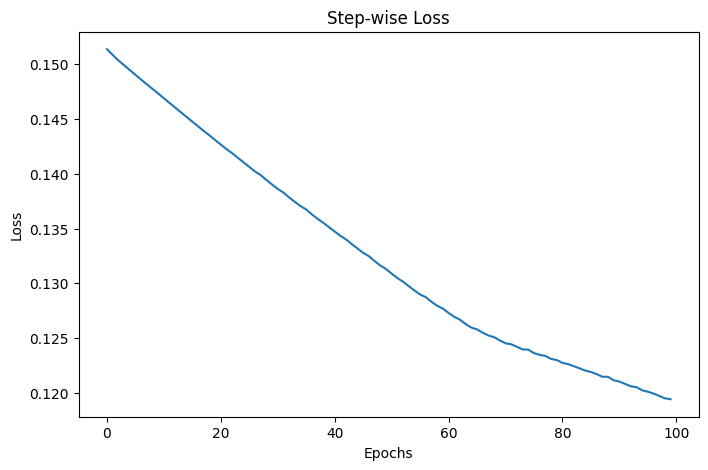

In [9]:
import matplotlib.pyplot as plt
learning_rate = 0.1

loss_fn = get_loss_function('mse')

num_epochs = 100
loss_values = []   # collect per-epoch average loss
acc = []

for j in range(num_epochs):
    l = []
    for i in range(len(x)):
        # single-sample forward
        out = model.forward_whole_network(x[i])         # forward
        l.append(loss_fn(out, y[i]))                    # record loss
        model.backward(x[i], y[i])                      # compute gradients
        model.update_weights()                          # apply update

    epoch_loss = float(sum(l) / len(l))
    loss_values.append(epoch_loss)
    print("epoch:", j + 1, "avg loss:", epoch_loss, "acc:", (1 - epoch_loss) * 100)
    acc.append((1 - epoch_loss) * 100)

print("Training Complete")

step = range(len(loss_values))
fig, ax = plt.subplots(figsize=(8,5))
plt.plot(step, np.array(loss_values))
plt.title("Step-wise Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

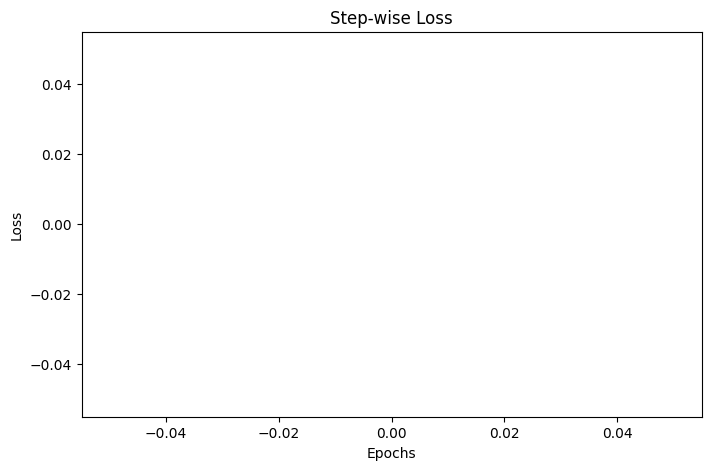

In [ ]:
from neural_network import NeuralNetwork

# get all params
params = model.get_params()

# inspect first layer weights
W0 = params['W1']
print("W0 shape:", W0.shape)

# # set params back (or modify then set)
# params['W0'] *= 0.5
# model.set_params(params)

# # or access directly inside class methods
# # e.g. add L2 term over weights
# weights = [layer.W for layer in model.layers if hasattr(layer, 'W')]
# l2_term = sum((W**2).sum() for W in weights) * 0.5 * model.l2_lambda

W0 shape: (10, 1)
